In [5]:
# INCLUDE_TERMS = [
#     # General / modern
#     "optical computing",
#     "photonic computing",
#     "silicon photonic processing",
#     "integrated photonic processing",

#     # Historical
#     "optical information processing",
#     "optical signal processing",
#     "photonic information processing",
#     "analog optical computing",
#     "free-space optical computing",
#     "optoelectronic computing",

#     # Architectures / functions
#     "optical matrix multiplication",
#     "optical correlator",
#     "optical pattern recognition",

#     # AI / neural
#     "optical neural network",
#     "photonic neural network",
#     "silicon photonic neural network",
#     "optical perceptron",
#     "photonic reservoir computing",
#     "neuromorphic photonics",

#     # Modern AI phrasing
#     "optical artificial intelligence",
# ]

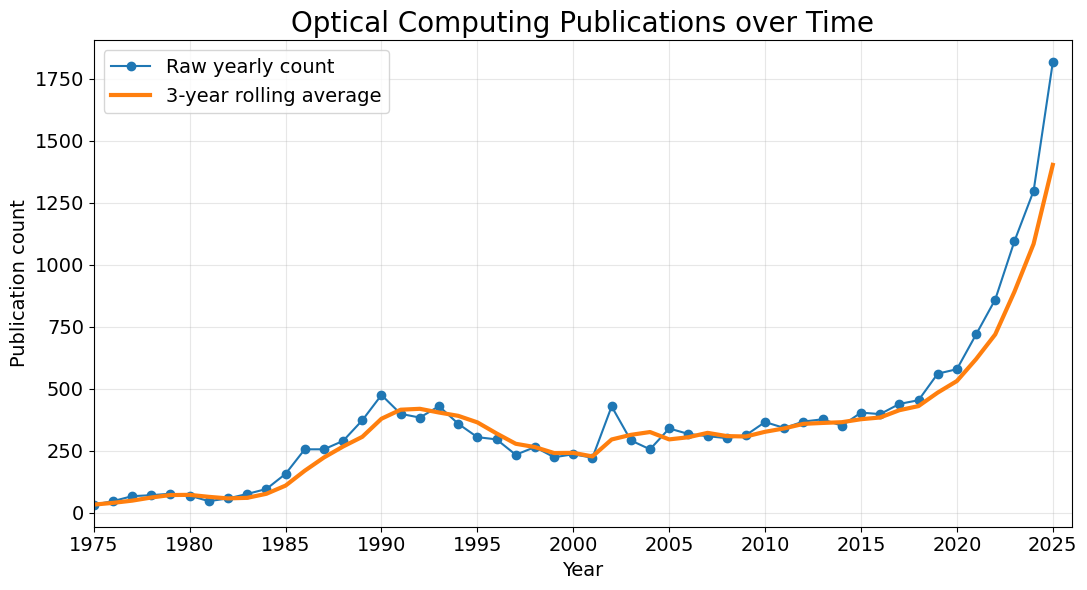

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

# Single CSV file
file = Path("./1975-2025.csv")

# Read file
combined = pd.read_csv(file)

# Clean types
combined["year"] = pd.to_numeric(combined["year"], errors="coerce")

for col in combined.columns:
    if col != "year":
        combined[col] = pd.to_numeric(combined[col], errors="coerce")

# Sort by year and remove duplicate years if any
combined = combined.sort_values("year").drop_duplicates(subset="year", keep="last")

# Pick count column automatically
if "count_final" in combined.columns:
    ycol = "count_final"
elif "count" in combined.columns:
    ycol = "count"
else:
    numeric_cols = combined.select_dtypes(include="number").columns.tolist()
    numeric_cols = [c for c in numeric_cols if c != "year"]
    if not numeric_cols:
        raise ValueError("No valid count column found.")
    ycol = numeric_cols[0]

# Drop rows missing year or count
combined = combined.dropna(subset=["year", ycol])

# Rolling average
rolling_window = 3
combined[f"{ycol}_rolling_{rolling_window}y"] = (
    combined[ycol].rolling(window=rolling_window, min_periods=1).mean()
)

# Save cleaned file
combined.to_csv("./combined_optical_computing_by_year.csv", index=False)

# Plot
plt.figure(figsize=(11, 6))

plt.plot(
    combined["year"],
    combined[ycol],
    marker="o",
    linewidth=1.5,
    label="Raw yearly count"
)

plt.plot(
    combined["year"],
    combined[f"{ycol}_rolling_{rolling_window}y"],
    linewidth=3,
    label=f"{rolling_window}-year rolling average"
)

plt.xlabel("Year", fontsize=14)
plt.ylabel("Publication count", fontsize=14)
plt.title("Optical Computing Publications over Time", fontsize=20)
plt.xticks(
    ticks=range(int(combined["year"].min()), 2026, 5),
    fontsize=14
)
plt.yticks(fontsize=14)
plt.xlim(1975, 2026)
plt.legend(fontsize=14)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(
    "../figures/optPubvsTime.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()

'/Users/blow/Library/CloudStorage/OneDrive-NECLaboratoriesAmerica/Conferences/COOL2026/Publication_Frequency/Attempt2'

# Plot Vs Baseline

,year,count_included_before_exclusion,count_excluded_matches,count_final,decade_source,total_publications,fraction_all,percent_all,percent_all_rolling_3y
0,1975,33,0,33,NaN,1100056,0.000030,0.003000,0.003000
1,1976,47,0,47,NaN,1115567,0.000042,0.004213,0.003606
2,1977,67,0,67,NaN,1159675,0.000058,0.005777,0.004330
3,1978,71,0,71,NaN,1209648,0.000059,0.005869,0.005287
4,1979,77,0,77,NaN,1256011,0.000061,0.006131,0.005926


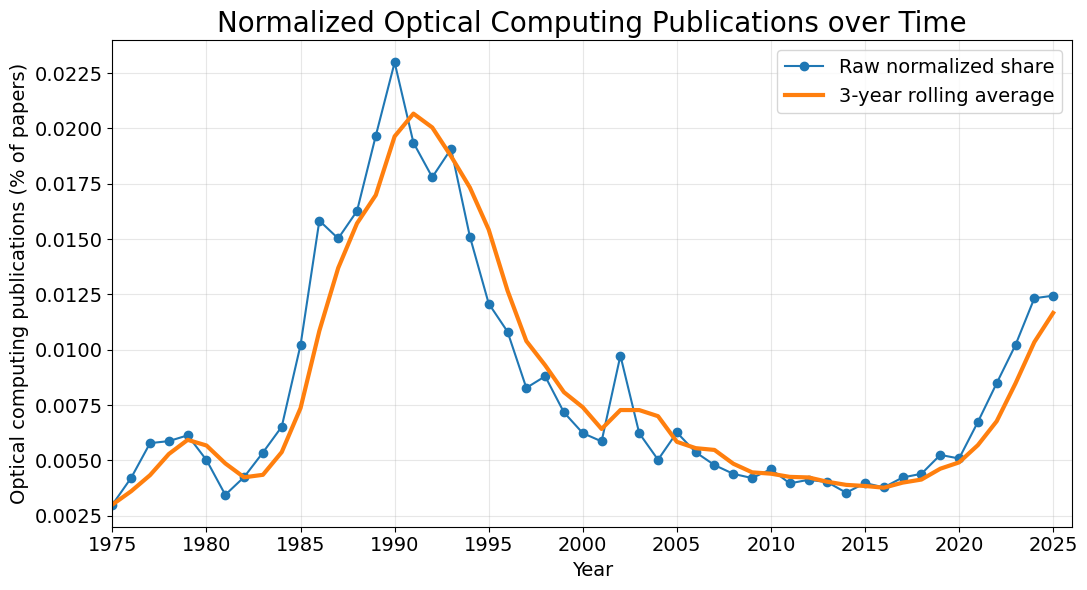

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

# -----------------------------
# File paths
# -----------------------------
optical_file = Path("./1975-2025.csv")
baseline_file = Path("../baseline_all_publications.csv")

# -----------------------------
# Load optical computing data
# -----------------------------
combined = pd.read_csv(optical_file)

combined["year"] = pd.to_numeric(combined["year"], errors="coerce")

for col in combined.columns:
    if col != "year":
        combined[col] = pd.to_numeric(combined[col], errors="coerce")

combined = combined.sort_values("year").drop_duplicates(subset="year", keep="last")

if "count_final" in combined.columns:
    ycol = "count_final"
elif "count" in combined.columns:
    ycol = "count"
else:
    numeric_cols = combined.select_dtypes(include="number").columns.tolist()
    numeric_cols = [c for c in numeric_cols if c != "year"]
    if not numeric_cols:
        raise ValueError("No valid count column found.")
    ycol = numeric_cols[0]

combined = combined.dropna(subset=["year", ycol])

# -----------------------------
# Load baseline data
# -----------------------------
baseline_df = pd.read_csv(baseline_file)

baseline_df["year"] = pd.to_numeric(baseline_df["year"], errors="coerce")

# auto-detect baseline count column
if "total_publications" in baseline_df.columns:
    baseline_col = "total_publications"
else:
    numeric_cols = baseline_df.select_dtypes(include="number").columns.tolist()
    numeric_cols = [c for c in numeric_cols if c != "year"]
    if not numeric_cols:
        raise ValueError("No valid baseline count column found.")
    baseline_col = numeric_cols[0]

baseline_df = (
    baseline_df[["year", baseline_col]]
    .dropna(subset=["year", baseline_col])
    .sort_values("year")
    .drop_duplicates(subset="year", keep="last")
)

# -----------------------------
# Merge and normalize
# -----------------------------
merged = combined.merge(baseline_df, on="year", how="inner")

merged["fraction_all"] = merged[ycol] / merged[baseline_col]
merged["percent_all"] = merged["fraction_all"] * 100

# Rolling average for normalized curve
rolling_window = 3
merged[f"percent_all_rolling_{rolling_window}y"] = (
    merged["percent_all"].rolling(window=rolling_window, min_periods=1).mean()
)

# Save merged normalized file
merged.to_csv("./optical_vs_baseline_normalized.csv", index=False)

display(merged.head())

# -----------------------------
# Plot normalized share
# -----------------------------
plt.figure(figsize=(11, 6))

plt.plot(
    merged["year"],
    merged["percent_all"],
    marker="o",
    linewidth=1.5,
    label="Raw normalized share"
)

plt.plot(
    merged["year"],
    merged[f"percent_all_rolling_{rolling_window}y"],
    linewidth=3,
    label=f"{rolling_window}-year rolling average"
)

plt.xlabel("Year", fontsize=14)
plt.ylabel("Optical computing publications (% of papers)", fontsize=14)
plt.title("Normalized Optical Computing Publications over Time", fontsize=20)
plt.xticks(
    ticks=range(int(merged["year"].min()), 2026, 5),
    fontsize=14
)
plt.yticks(fontsize=14)
plt.xlim(1975, 2026)
plt.legend(fontsize=14)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(
    "../figures/optPubvsTimeBaselineAll.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()

,year,count_included_before_exclusion,count_excluded_matches,count_final,decade_source,cs_ee_total_publications,fraction_cs_ee,percent_cs_ee,percent_cs_ee_rolling_3y
0,1975,33,0,33,NaN,24458,0.001349,0.134925,0.134925
1,1976,47,0,47,NaN,24449,0.001922,0.192237,0.163581
2,1977,67,0,67,NaN,26120,0.002565,0.256508,0.194557
3,1978,71,0,71,NaN,27222,0.002608,0.260818,0.236521
4,1979,77,0,77,NaN,28607,0.002692,0.269165,0.262164


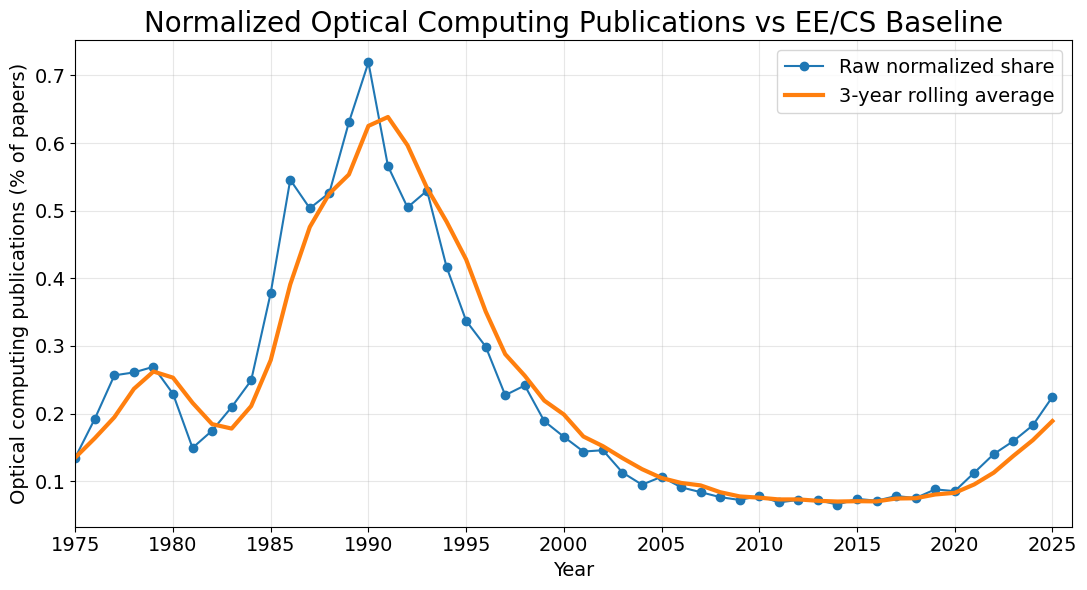

In [3]:
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

# -----------------------------
# File paths
# -----------------------------
optical_file = Path("./1975-2025.csv")
baseline_file = Path("../baseline_cs_ee_publications.csv")

# -----------------------------
# Load optical computing data
# -----------------------------
combined = pd.read_csv(optical_file)

combined["year"] = pd.to_numeric(combined["year"], errors="coerce")

for col in combined.columns:
    if col != "year":
        combined[col] = pd.to_numeric(combined[col], errors="coerce")

combined = combined.sort_values("year").drop_duplicates(subset="year", keep="last")

if "count_final" in combined.columns:
    ycol = "count_final"
elif "count" in combined.columns:
    ycol = "count"
else:
    numeric_cols = combined.select_dtypes(include="number").columns.tolist()
    numeric_cols = [c for c in numeric_cols if c != "year"]
    if not numeric_cols:
        raise ValueError("No valid count column found.")
    ycol = numeric_cols[0]

combined = combined.dropna(subset=["year", ycol])

# -----------------------------
# Load baseline data
# -----------------------------
baseline_df = pd.read_csv(baseline_file)

baseline_df["year"] = pd.to_numeric(baseline_df["year"], errors="coerce")

# auto-detect baseline count column
if "cs_ee_total_publications" in baseline_df.columns:
    baseline_col = "cs_ee_total_publications"
elif "total_publications" in baseline_df.columns:
    baseline_col = "total_publications"
else:
    numeric_cols = baseline_df.select_dtypes(include="number").columns.tolist()
    numeric_cols = [c for c in numeric_cols if c != "year"]
    if not numeric_cols:
        raise ValueError("No valid baseline count column found.")
    baseline_col = numeric_cols[0]

baseline_df = (
    baseline_df[["year", baseline_col]]
    .dropna(subset=["year", baseline_col])
    .sort_values("year")
    .drop_duplicates(subset="year", keep="last")
)

# -----------------------------
# Merge and normalize
# -----------------------------
merged = combined.merge(baseline_df, on="year", how="inner")

merged["fraction_cs_ee"] = merged[ycol] / merged[baseline_col]
merged["percent_cs_ee"] = merged["fraction_cs_ee"] * 100

# Rolling average for normalized curve
rolling_window = 3
merged[f"percent_cs_ee_rolling_{rolling_window}y"] = (
    merged["percent_cs_ee"].rolling(window=rolling_window, min_periods=1).mean()
)

# Save merged normalized file
merged.to_csv("./optical_vs_cs_ee_normalized.csv", index=False)

display(merged.head())

# -----------------------------
# Plot normalized share
# -----------------------------
plt.figure(figsize=(11, 6))

plt.plot(
    merged["year"],
    merged["percent_cs_ee"],
    marker="o",
    linewidth=1.5,
    label="Raw normalized share"
)

plt.plot(
    merged["year"],
    merged[f"percent_cs_ee_rolling_{rolling_window}y"],
    linewidth=3,
    label=f"{rolling_window}-year rolling average"
)

plt.xlabel("Year", fontsize=14)
plt.ylabel("Optical computing publications (% of papers)", fontsize=14)
plt.title("Normalized Optical Computing Publications vs EE/CS Baseline", fontsize=20)
plt.xticks(
    ticks=range(int(merged["year"].min()), 2026, 5),
    fontsize=14
)
plt.yticks(fontsize=14)
plt.xlim(1975, 2026)
plt.legend(fontsize=14)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(
    "../figures/optPubvsTimeEECSBaseline.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()

,year,count_included_before_exclusion,count_excluded_matches,count_final,decade_source,optical_total_publications,fraction_optical,percent_optical,percent_optical_rolling_3y
0,1975,33,0,33,NaN,15610,0.002114,0.211403,0.211403
1,1976,47,0,47,NaN,16818,0.002795,0.279462,0.245433
2,1977,67,0,67,NaN,18468,0.003628,0.362790,0.284552
3,1978,71,0,71,NaN,19218,0.003694,0.369445,0.337232
4,1979,77,0,77,NaN,19545,0.003940,0.393963,0.375399


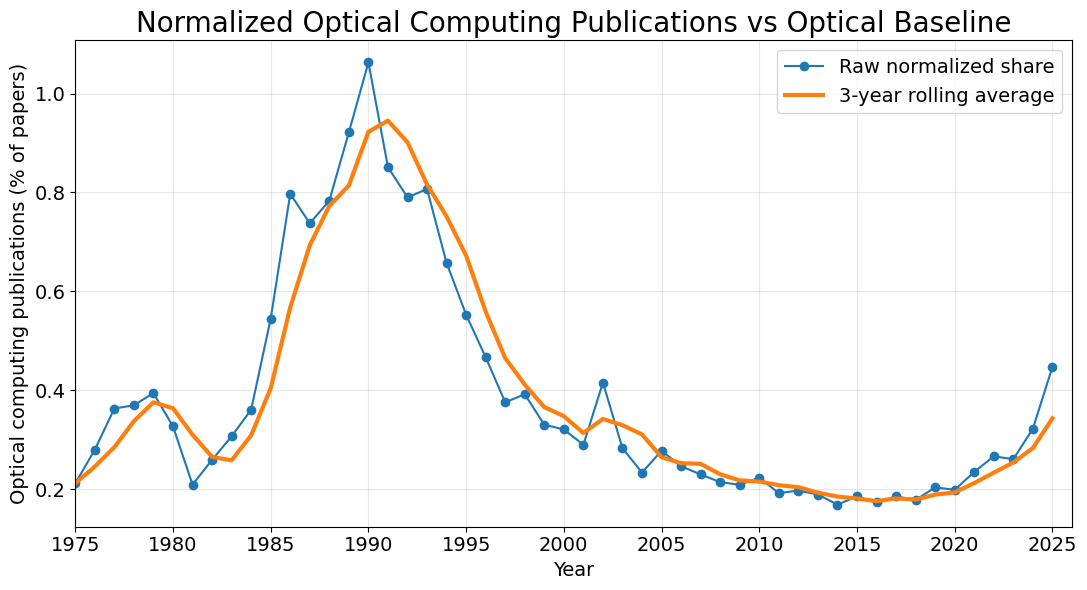

In [4]:
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

# -----------------------------
# File paths
# -----------------------------
optical_file = Path("./1975-2025.csv")
baseline_file = Path("../baseline_optical_publications.csv")

# -----------------------------
# Load optical computing data
# -----------------------------
combined = pd.read_csv(optical_file)

combined["year"] = pd.to_numeric(combined["year"], errors="coerce")

for col in combined.columns:
    if col != "year":
        combined[col] = pd.to_numeric(combined[col], errors="coerce")

combined = combined.sort_values("year").drop_duplicates(subset="year", keep="last")

if "count_final" in combined.columns:
    ycol = "count_final"
elif "count" in combined.columns:
    ycol = "count"
else:
    numeric_cols = combined.select_dtypes(include="number").columns.tolist()
    numeric_cols = [c for c in numeric_cols if c != "year"]
    if not numeric_cols:
        raise ValueError("No valid count column found.")
    ycol = numeric_cols[0]

combined = combined.dropna(subset=["year", ycol])

# -----------------------------
# Load baseline data
# -----------------------------
baseline_df = pd.read_csv(baseline_file)

baseline_df["year"] = pd.to_numeric(baseline_df["year"], errors="coerce")

# auto-detect baseline count column
if "optical_total_publications" in baseline_df.columns:
    baseline_col = "optical_total_publications"
elif "total_publications" in baseline_df.columns:
    baseline_col = "total_publications"
else:
    numeric_cols = baseline_df.select_dtypes(include="number").columns.tolist()
    numeric_cols = [c for c in numeric_cols if c != "year"]
    if not numeric_cols:
        raise ValueError("No valid baseline count column found.")
    baseline_col = numeric_cols[0]

baseline_df = (
    baseline_df[["year", baseline_col]]
    .dropna(subset=["year", baseline_col])
    .sort_values("year")
    .drop_duplicates(subset="year", keep="last")
)

# -----------------------------
# Merge and normalize
# -----------------------------
merged = combined.merge(baseline_df, on="year", how="inner")

merged["fraction_optical"] = merged[ycol] / merged[baseline_col]
merged["percent_optical"] = merged["fraction_optical"] * 100

# Rolling average for normalized curve
rolling_window = 3
merged[f"percent_optical_rolling_{rolling_window}y"] = (
    merged["percent_optical"].rolling(window=rolling_window, min_periods=1).mean()
)

# Save merged normalized file
merged.to_csv("./optical_vs_optical_baseline_normalized.csv", index=False)

display(merged.head())

# -----------------------------
# Plot normalized share
# -----------------------------
plt.figure(figsize=(11, 6))

plt.plot(
    merged["year"],
    merged["percent_optical"],
    marker="o",
    linewidth=1.5,
    label="Raw normalized share"
)

plt.plot(
    merged["year"],
    merged[f"percent_optical_rolling_{rolling_window}y"],
    linewidth=3,
    label=f"{rolling_window}-year rolling average"
)

plt.xlabel("Year", fontsize=14)
plt.ylabel("Optical computing publications (% of papers)", fontsize=14)
plt.title("Normalized Optical Computing Publications vs Optical Baseline", fontsize=20)
plt.xticks(
    ticks=range(int(merged["year"].min()), 2026, 5),
    fontsize=14
)
plt.yticks(fontsize=14)
plt.xlim(1975, 2026)
plt.legend(fontsize=14)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(
    "../figures/optPubvsTimeOptBaseline.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()

## Optical Baseline restricted with EE / CS subfields 

,year,count_included_before_exclusion,count_excluded_matches,count_final,decade_source,optical_cs_ee_subfield_publications,fraction_optical_cs_ee,percent_optical_cs_ee,percent_optical_cs_ee_rolling_3y
0,1975,33,0,33,NaN,3464,0.009527,0.952656,0.952656
1,1976,47,0,47,NaN,3657,0.012852,1.285206,1.118931
2,1977,67,0,67,NaN,3697,0.018123,1.812280,1.350048
3,1978,71,0,71,NaN,3841,0.018485,1.848477,1.648655
4,1979,77,0,77,NaN,4335,0.017762,1.776240,1.812332


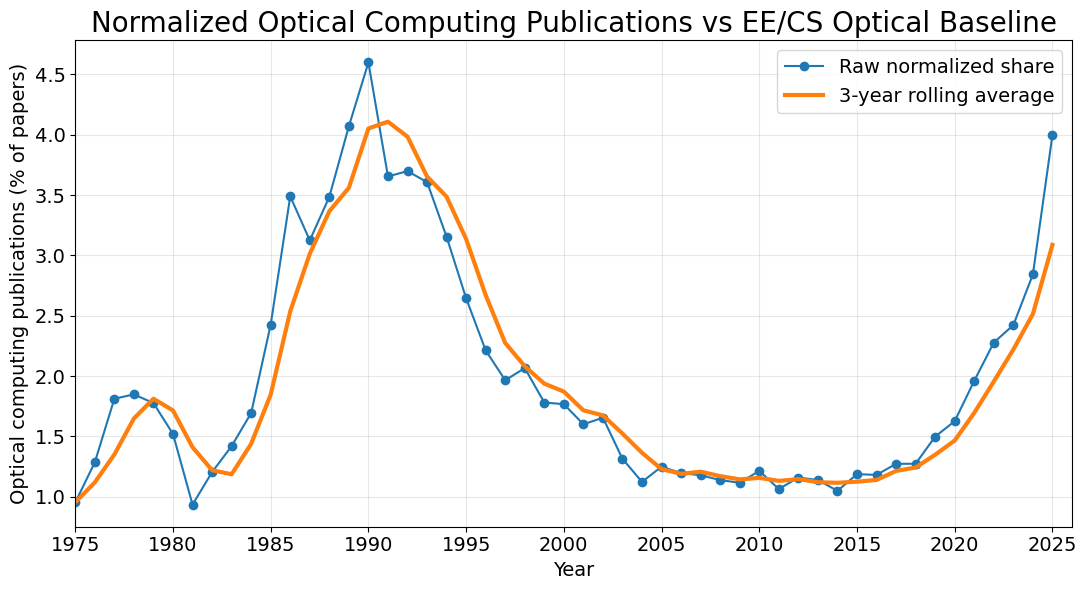

In [5]:
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

# -----------------------------
# File paths
# -----------------------------
optical_file = Path("./1975-2025.csv")
baseline_file = Path("../baseline_optical_cs_ee_subfields.csv")

# -----------------------------
# Load optical computing data
# -----------------------------
combined = pd.read_csv(optical_file)

combined["year"] = pd.to_numeric(combined["year"], errors="coerce")

for col in combined.columns:
    if col != "year":
        combined[col] = pd.to_numeric(combined[col], errors="coerce")

combined = combined.sort_values("year").drop_duplicates(subset="year", keep="last")

if "count_final" in combined.columns:
    ycol = "count_final"
elif "count" in combined.columns:
    ycol = "count"
else:
    numeric_cols = combined.select_dtypes(include="number").columns.tolist()
    numeric_cols = [c for c in numeric_cols if c != "year"]
    if not numeric_cols:
        raise ValueError("No valid count column found.")
    ycol = numeric_cols[0]

combined = combined.dropna(subset=["year", ycol])

# -----------------------------
# Load constrained optical baseline data
# -----------------------------
baseline_df = pd.read_csv(baseline_file)

baseline_df["year"] = pd.to_numeric(baseline_df["year"], errors="coerce")

# auto-detect baseline count column
if "optical_cs_ee_subfield_publications" in baseline_df.columns:
    baseline_col = "optical_cs_ee_subfield_publications"
elif "optical_total_publications" in baseline_df.columns:
    baseline_col = "optical_total_publications"
elif "total_publications" in baseline_df.columns:
    baseline_col = "total_publications"
else:
    numeric_cols = baseline_df.select_dtypes(include="number").columns.tolist()
    numeric_cols = [c for c in numeric_cols if c != "year"]
    if not numeric_cols:
        raise ValueError("No valid baseline count column found.")
    baseline_col = numeric_cols[0]

baseline_df = (
    baseline_df[["year", baseline_col]]
    .dropna(subset=["year", baseline_col])
    .sort_values("year")
    .drop_duplicates(subset="year", keep="last")
)

# -----------------------------
# Merge and normalize
# -----------------------------
merged = combined.merge(baseline_df, on="year", how="inner")

merged["fraction_optical_cs_ee"] = merged[ycol] / merged[baseline_col]
merged["percent_optical_cs_ee"] = merged["fraction_optical_cs_ee"] * 100

# Rolling average for normalized curve
rolling_window = 3
merged[f"percent_optical_cs_ee_rolling_{rolling_window}y"] = (
    merged["percent_optical_cs_ee"].rolling(window=rolling_window, min_periods=1).mean()
)

# Save merged normalized file
merged.to_csv("./optical_vs_optical_cs_ee_subfields_normalized.csv", index=False)

display(merged.head())

# -----------------------------
# Plot normalized share
# -----------------------------
plt.figure(figsize=(11, 6))

plt.plot(
    merged["year"],
    merged["percent_optical_cs_ee"],
    marker="o",
    linewidth=1.5,
    label="Raw normalized share"
)

plt.plot(
    merged["year"],
    merged[f"percent_optical_cs_ee_rolling_{rolling_window}y"],
    linewidth=3,
    label=f"{rolling_window}-year rolling average"
)

plt.xlabel("Year", fontsize=14)
plt.ylabel("Optical computing publications (% of papers)", fontsize=14)
plt.title("Normalized Optical Computing Publications vs EE/CS Optical Baseline", fontsize=20)
plt.xticks(
    ticks=range(int(merged["year"].min()), 2026, 5),
    fontsize=14
)
plt.yticks(fontsize=14)
plt.xlim(1975, 2026)
plt.legend(fontsize=14)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(
    "../figures/optPubvsTimeEECSOptBaseline.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()